In [1]:
import pandas as pd
import matplotlib.pyplot as plt

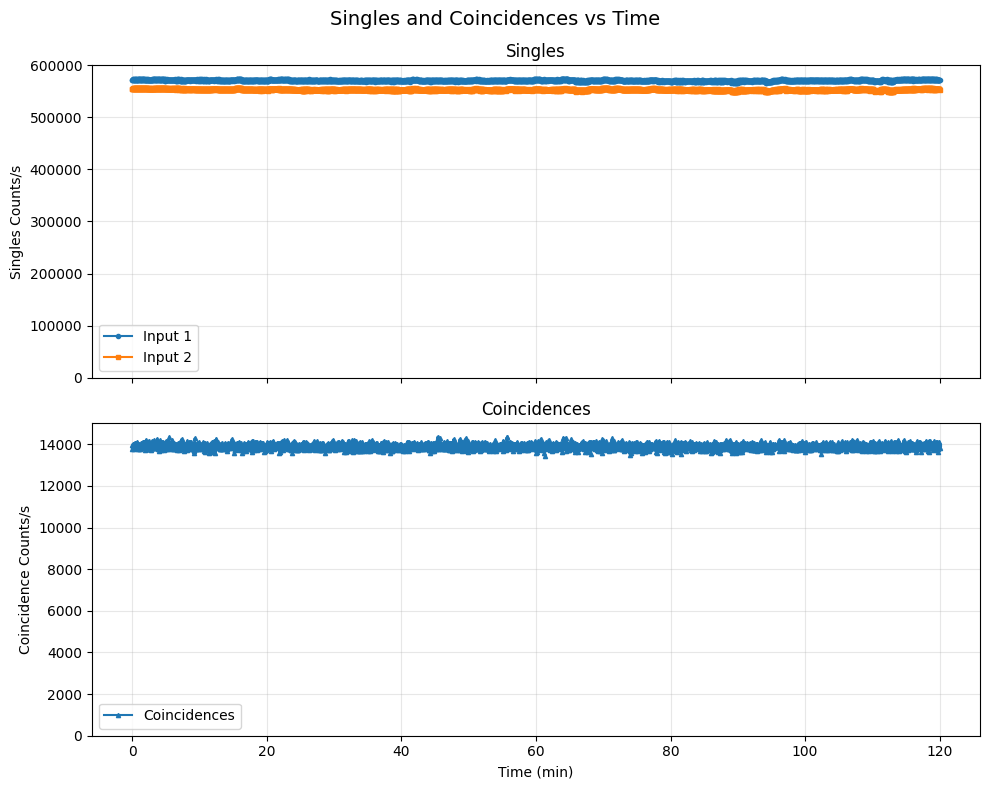

In [6]:


# Load the CSV file
filename = "counters_eff_20_DT_1us_50MHz_T_2hrs.csv"

# Read the data
df = pd.read_csv(filename, sep=';')

# Convert columns to numeric
cols = ['time', 'input 1', 'input 2', '1/2']
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

# Convert time from seconds to minutes
df['time_min'] = df['time'] / 60

# Create two stacked subplots
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True
)

# Top plot: Singles
ax1.plot(df['time_min'], df['input 1'],
         marker='o', linestyle='-',
         markersize=3, label='Input 1')

ax1.plot(df['time_min'], df['input 2'],
         marker='s', linestyle='-',
         markersize=3, label='Input 2')

ax1.set_ylabel('Singles Counts/s')
ax1.set_title('Singles')
ax1.set_ylim([0,600000])
ax1.grid(True, alpha=0.3)
ax1.legend()

# Bottom plot: Coincidences
ax2.plot(df['time_min'], df['1/2'],
         marker='^', linestyle='-',
         markersize=3, label='Coincidences')

ax2.set_xlabel('Time (min)')
ax2.set_ylabel('Coincidence Counts/s')
ax2.set_title('Coincidences')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0,15000])
ax2.legend()

# Overall figure title
fig.suptitle('Singles and Coincidences vs Time', fontsize=14)

plt.tight_layout()
plt.show()